# Bacon–Shor CPU decoder review

**[DEMO]** dedicated SE，LightStim 自动 detectors。CPU BPOSD 与 MWPM 的同样本比较。
Z memory，d 个 XZ pairs，reset/ancilla readout flips p，CX depolarization p，无 idle noise，final data readout 理想。
默认 baseline：MWPM + Z-record detectors；完整 XZ DEM 含 hyperedges。


In [1]:
from pathlib import Path
import sys, json
ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "lightstim").is_dir())
if str(ROOT) not in sys.path: sys.path.insert(0,str(ROOT))
from benchmarks.memory.bacon_shor_schedule.decoder_review import build, detector_rows, OUT, PARAMS
from benchmarks.memory.bacon_shor_schedule.run import select_basis_detectors
from lightstim.simulation.decoder_backend import get_decoder
from IPython.display import Image, display
import numpy as np
import pandas as pd
full = build(3, .001)
selected = select_basis_detectors(full, "Z")
print("full / selected detectors:", full.num_detectors, selected.num_detectors)
print("BPOSD CPU parameters:", dict(PARAMS, schedule="serial"))
print("Selected detector indices:", detector_rows(full))

full / selected detectors: 16 12
BPOSD CPU parameters: {'max_iterations': 100, 'osd_order': 10, 'osd_method': 'osd_cs', 'bp_method': 'min_sum', 'ms_scaling_factor': 0, 'schedule': 'serial'}
Selected detector indices: [ 0  1  4  5  8  9 10 11 12 13 14 15]


## 已完成的 scaling

黑圈表示不足 100 个 errors；低 p、大 d 的误差条较宽。LER 为完整 shot。

,d,p,decoder,errors,shots,ler,ci_low,ci_high,status
0,3,0.0005,bposd_z_serial,100,832000,0.000120,9.779430e-05,0.000146,error_target
1,3,0.0005,mwpm_z,100,832000,0.000120,9.779430e-05,0.000146,error_target
2,3,0.0010,bposd_full_parallel,100,132000,0.000758,6.164351e-04,0.000921,error_target
3,3,0.0010,bposd_full_serial,100,140000,0.000714,5.812080e-04,0.000869,error_target
4,3,0.0010,bposd_z_serial,101,157000,0.000643,5.240179e-04,0.000782,error_target
5,3,0.0010,mwpm_z,101,157000,0.000643,5.240179e-04,0.000782,error_target
6,3,0.0020,bposd_z_serial,100,43000,0.002326,1.892574e-03,0.002828,error_target
7,3,0.0020,mwpm_z,100,43000,0.002326,1.892574e-03,0.002828,error_target
8,5,0.0005,bposd_z_serial,59,2000000,0.000029,2.245684e-05,0.000038,shot_cap
9,5,0.0005,mwpm_z,59,2000000,0.000029,2.245684e-05,0.000038,shot_cap


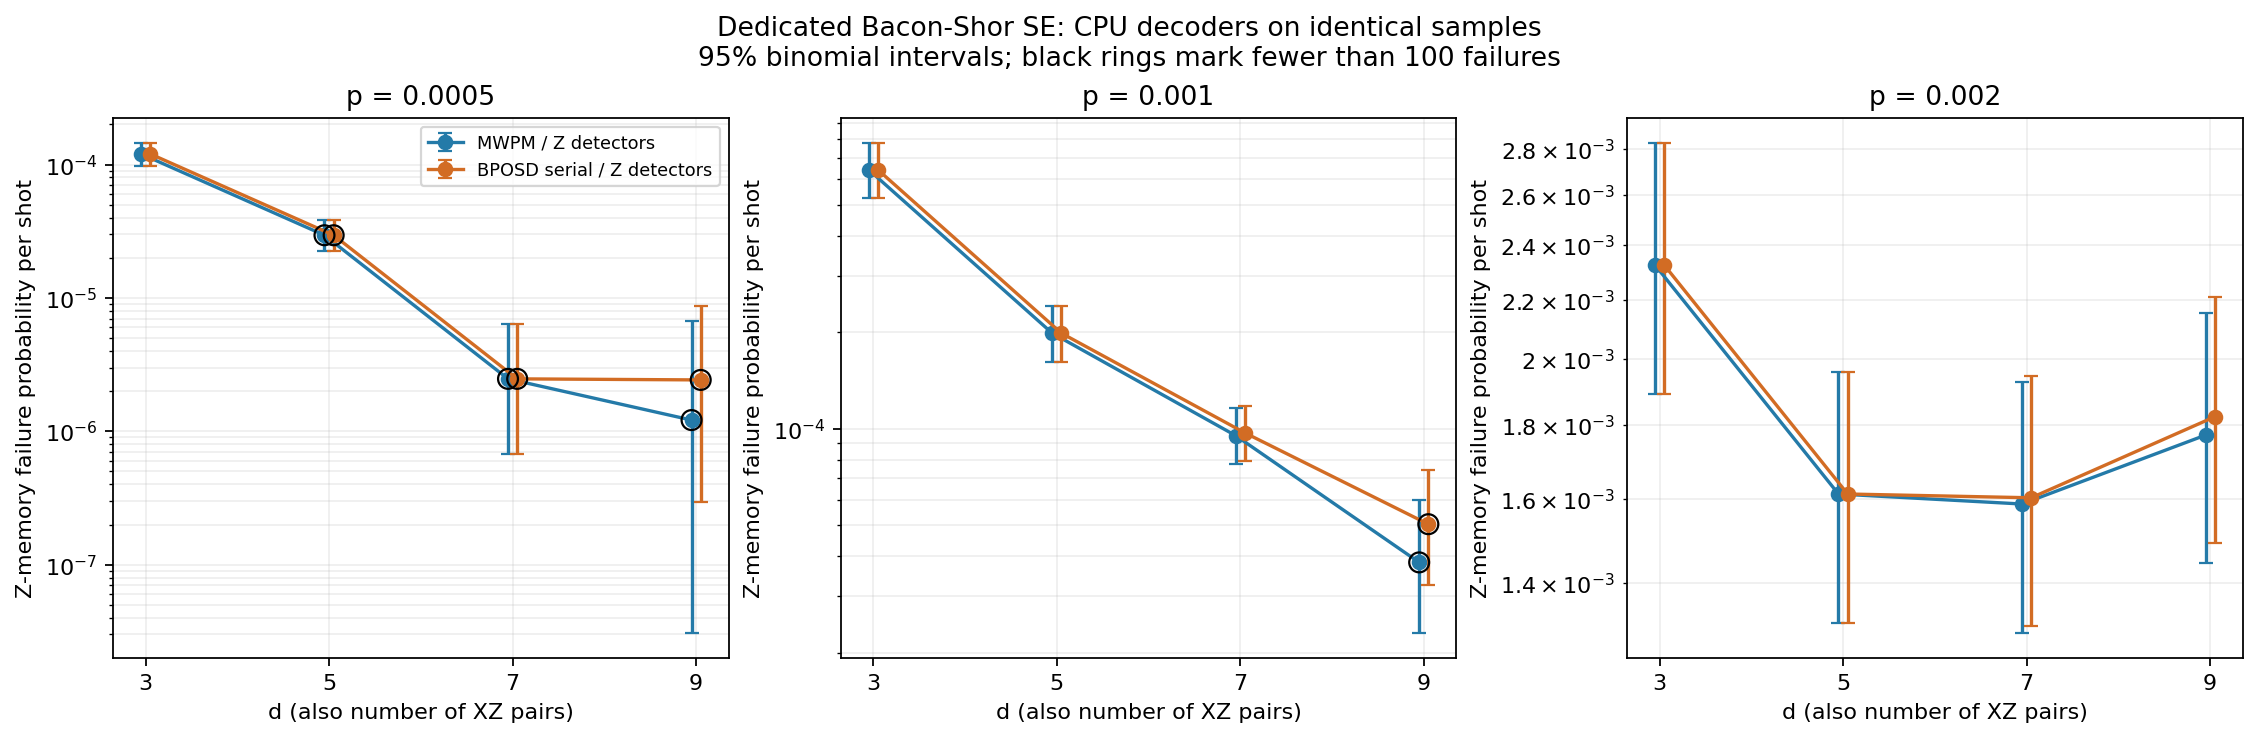

In [2]:
data = pd.read_csv(OUT / "decoders.csv")
display(data[["d","p","decoder","errors","shots","ler","ci_low","ci_high","status"]])
display(Image(filename=str(OUT / "decoder_scaling.png")))

## 验证一次真实的 decoder 调用

复用保存的 first batch，通过 LightStim decoder registry 重算 MWPM 和 BPOSD。

In [3]:
saved = np.load(OUT / "d3_p0.001_z_pair_first_batch.npz")
for name, params in [("pymatching", {}), ("bposd", dict(PARAMS, schedule="serial"))]:
    decoder = get_decoder(name, **params).compile_decoder_for_dem(dem=selected.detector_error_model())
    pred = decoder.decode_shots_bit_packed(bit_packed_detection_event_data=saved["decoder_detectors"])
    key = "mwpm_z" if name == "pymatching" else "bposd_z_serial"
    assert np.array_equal(pred, saved[key])
    print(name, "reproduced saved predictions; failures:", int(((pred ^ saved["observables"]) & 1).any(axis=1).sum()))

pymatching reproduced saved predictions; failures: 1
bposd reproduced saved predictions; failures: 1


## 配对差异与 decoder CPU 用时

BP parallel 指消息更新顺序，不是 GPU。用时是共享机器上的实际 decode time，不能视为独立硬件 benchmark。

In [4]:
summary = json.loads((OUT / "summary.json").read_text())
display(pd.DataFrame(summary["paired"]))
display(data[["d","p","decoder","decode_seconds","decode_shots_per_second"]])
audit = json.loads((OUT / "single_fault_audit.json").read_text())
assert all(v["bad_count"] == 0 for r in audit for v in r["profiles"].values())
print("Single-mechanism audit:", [(r["d"],r["error_mechanisms"]) for r in audit])

Single-mechanism audit: [(3, 105), (5, 623), (7, 1837), (9, 4035)]


,both,bposd_only,d,mwpm_only,nominal_pvalue,p,shots
0,100,0,3,0,1.000000,0.0005,832000
1,101,0,3,0,1.000000,0.0010,157000
2,100,0,3,0,1.000000,0.0020,43000
3,59,0,5,0,1.000000,0.0005,2000000
4,100,0,5,0,1.000000,0.0010,503000
5,100,0,5,0,1.000000,0.0020,62000
6,4,0,7,0,1.000000,0.0005,1618000
7,100,2,7,0,0.500000,0.0010,1050000
8,97,4,7,3,1.000000,0.0020,63000
9,1,1,9,0,1.000000,0.0005,824000


,d,p,decoder,decode_seconds,decode_shots_per_second
0,3,0.0005,bposd_z_serial,13.073991,6.363780e+04
1,3,0.0005,mwpm_z,0.107054,7.771764e+06
2,3,0.0010,bposd_full_parallel,2.809171,4.698895e+04
3,3,0.0010,bposd_full_serial,3.584385,3.905830e+04
4,3,0.0010,bposd_z_serial,2.939815,5.340472e+04
5,3,0.0010,mwpm_z,0.023511,6.677799e+06
6,3,0.0020,bposd_z_serial,0.994628,4.323223e+04
7,3,0.0020,mwpm_z,0.009214,4.666614e+06
8,5,0.0005,bposd_z_serial,54.160993,3.692695e+04
9,5,0.0005,mwpm_z,0.568670,3.516980e+06


## 继续运行的入口

`benchmarks/memory/bacon_shor_schedule/decoder_review.py` 可按 checkpoint 续跑，`--max-seconds` 增加每 job 总时间预算；每个 job 的 max_shots 默认 2M。
配对 benchmark 直接使用 LightStim registry，以保存同样本的多 decoder predictions。常规非配对采样也可将 `selected` 交给 `SimulationPipeline(DecoderConfig("pymatching"), ...)`。
正式 dedicated SE 与原生 noise / MWPM demo 见 [memory_bacon_shor.ipynb](../../notebooks/Memory/memory_bacon_shor.ipynb)。
